# CODSOFT - Data Science Internship

## Task 1: Titanic Survival Prediction

### Objective

The objective of this project is to build a machine learning model that predicts whether a passenger on the Titanic survived or did not survive.

### Dataset

The Titanic dataset contains information about passengers, including passenger class, name, gender, age, number of siblings or spouses, parents or children aboard, ticket information, fare, cabin, and embarkation port.

### Machine Learning Approach

A Random Forest Classification model is used to predict passenger survival. The model is evaluated using accuracy, classification report, and confusion matrix.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [19]:
print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSurvival Distribution:")
print(df["Survived"].value_counts())

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             

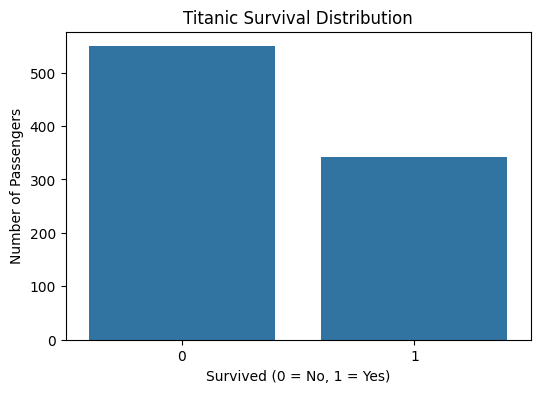

In [20]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

In [21]:
data = df[[
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Survived"
]].copy()

data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0


In [22]:
# Fill missing Age values with the median age
data["Age"] = data["Age"].fillna(data["Age"].median())

# Convert Sex into numerical values
data["Sex"] = data["Sex"].map({
    "male": 0,
    "female": 1
})

print("Missing values after cleaning:")
print(data.isnull().sum())

Missing values after cleaning:
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Survived    0
dtype: int64


In [23]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Survived")

Features:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']

Target:
Survived


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 712
Testing samples: 179


In [25]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [26]:
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 0 0 0 1 0 1 1 0 0]


In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 81.56 %


In [28]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Did Not Survive", "Survived"]
))

                 precision    recall  f1-score   support

Did Not Survive       0.83      0.88      0.85       110
       Survived       0.79      0.71      0.75        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.82      0.81       179



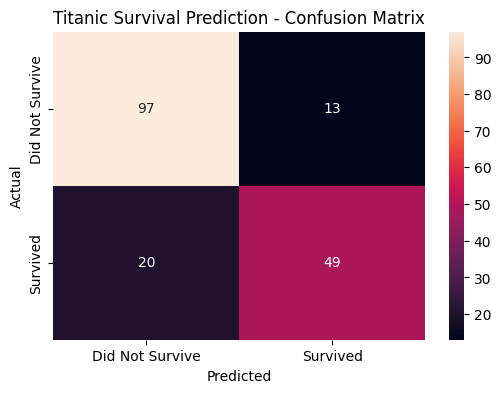

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Titanic Survival Prediction - Confusion Matrix")

plt.show()

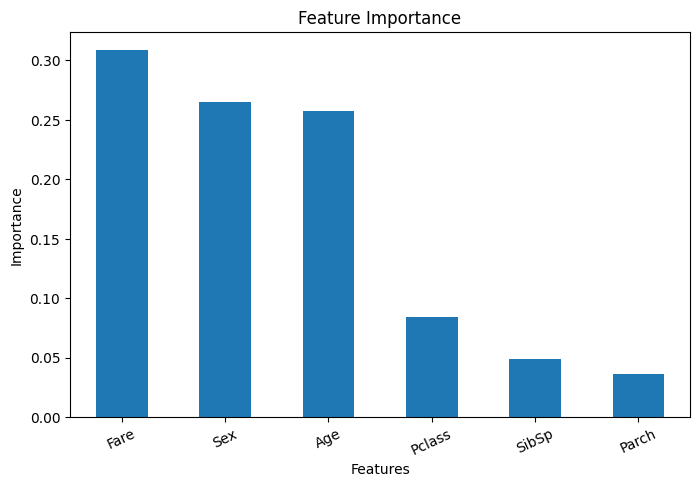

In [30]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=25)

plt.show()

In [ ]:
# [Pclass, Sex, Age, SibSp, Parch, Fare]

new_passenger = [[3, 0, 22, 1, 0, 7.25]]

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Prediction: Passenger Survived")
else:
    print("Prediction: Passenger Did Not Survive")

## Conclusion

In this project, a Random Forest Classification model was developed to predict whether a passenger survived the Titanic disaster.

The actual Titanic dataset was explored and preprocessed before training the model. Features such as passenger class, gender, age, family information, and fare were used for prediction.

The model was evaluated using accuracy, classification report, and confusion matrix. Feature importance was also analyzed to understand the contribution of different passenger attributes.

This project demonstrates the complete machine learning workflow, including data loading, data preprocessing, visualization, model training, prediction, and evaluation.
